In [1]:
import numpy as np
from math import sqrt # calcula raíces cuadrada
from pprint import pprint # pretty printer, muestra estructuras de datos de forma más legible en pantalla
from sklearn import datasets # proporciona datasets de ejemplo listos para usar
from sklearn.dummy import DummyRegressor # modelo de regresión "tonto" que predice siempre el mismo valor (la media, por ejemplo)
from sklearn.model_selection import cross_validate # validacion cruzada
from sklearn.model_selection import KFold # dividir los datos en K partes
from sklearn.metrics import make_scorer # métricas para medir qué tan bien predice el modelo
from sklearn.metrics import mean_squared_error #  métricas para medir qué tan bien predice el modelo
from sklearn.model_selection import train_test_split # divide los datos en conjunto de entrenamiento y test
from sklearn.svm import SVR # Support Vector Regression el modelo principal
from sklearn.metrics import mean_absolute_error #  métricas para medir qué tan bien predice el modelo
import matplotlib.pyplot as plt #  librería estándar para hacer gráficas
from sklearn import preprocessing # ransformar los datos antes de entrenarlos, como normalizar o estandarizar
from sklearn.metrics import r2_score # métrica de evaluación para modelos de regresión, conocida como coeficiente de determinación o R²

In [2]:
# Cargar y explorar los datos
datos = datasets.load_diabetes()
pprint(datos)
print(np.shape(datos.data))

{'DESCR': '.. _diabetes_dataset:\n'
          '\n'
          'Diabetes dataset\n'
          '----------------\n'
          '\n'
          'Ten baseline variables, age, sex, body mass index, average blood\n'
          'pressure, and six blood serum measurements were obtained for each '
          'of n =\n'
          '442 diabetes patients, as well as the response of interest, a\n'
          'quantitative measure of disease progression one year after '
          'baseline.\n'
          '\n'
          '**Data Set Characteristics:**\n'
          '\n'
          ':Number of Instances: 442\n'
          '\n'
          ':Number of Attributes: First 10 columns are numeric predictive '
          'values\n'
          '\n'
          ':Target: Column 11 is a quantitative measure of disease progression '
          'one year after baseline\n'
          '\n'
          ':Attribute Information:\n'
          '    - age     age in years\n'
          '    - sex\n'
          '    - bmi     body mass index\n'

In [3]:
# Extraer la matriz de datos "X" y la variable target "y"
X = datos.data
y = datos.target

In [4]:
# Partición EXTERNA: hold-out split 80% train - 20% test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # random_state=42 es la semilla aleatoria

In [5]:
# Estandarización de los datos de entrenamiento y test
stdr = preprocessing.StandardScaler() # Llamar a la clase y guardarla en una variable
X_train = stdr.fit_transform(X_train) # Ajustar y transformar los datos de entrenamiento
X_test = stdr.transform(X_test) # Solo transformar los datos de test

In [6]:
# Métricas de evaluación.
metricas = {
  'MAE': 'neg_mean_absolute_error',
  'RMSE': make_scorer(lambda y, y_pred:
                      sqrt(mean_squared_error(y, y_pred)),
                      greater_is_better=False),
  'MAPE': make_scorer(lambda y, y_pred:
                      np.mean(np.abs((y - y_pred) / y)) * 100,
                      greater_is_better=False)}

In [7]:
# Definimos un algoritmo SVM de regresión
alg = SVR(C=100, gamma="auto", kernel="rbf")

In [8]:
# Validación y evaluación del modelo.
# en "cv = KFold(n_splits=5)" se hace un cross-validation INTERNO!!
results = cross_validate(alg, X_train, y_train, cv = KFold(n_splits=5, shuffle=True, random_state=42), scoring = metricas)
  #alg: el algoritmo
  #X_train
  #y_train

In [9]:
# Presentación de los resultados de la evaluación.
pprint(results)

{'fit_time': array([0.05869126, 0.02223301, 0.04375076, 0.04115343, 0.01621103]),
 'score_time': array([0.00844717, 0.01625228, 0.01576495, 0.00442982, 0.00602889]),
 'test_MAE': array([-47.44758455, -50.66603276, -45.27769787, -40.54446486,
       -51.4810195 ]),
 'test_MAPE': array([-30.09985457, -44.00488088, -38.42439408, -38.98784535,
       -47.16943591]),
 'test_RMSE': array([-59.88968332, -59.4922535 , -58.45873745, -52.62662357,
       -66.31327837])}


aqui entre medias deberia hacerse un estudio de los hiperparámetros

In [10]:
# Una vez hemos optimizado los hiperparámetros en el conjunto de validación, entrenamos un nuevo modelo que contenga
# todos los datos de entrenamiento (es decir, train + validation) para evaluar el test
model = SVR(C=10, gamma='scale', kernel='rbf')
model = model.fit(X_train, y_train)

In [11]:
# Extraemos el error absoluto promedio (MAE) del conjunto de test
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
print('Test results (MAE): ', mae)

Test results (MAE):  41.319671295107455


In [12]:
# También podemos extraer las predicciones para cuánto difieren los valores predichos de los reales
print('Predicciones:   ', np.round(y_pred[:10], 1))
print('Valores reales: ', y_test[:10])

Predicciones:    [149.  172.2 152.9 212.3 110.1 122.3 227.3 191.8 106.7 103.9]
Valores reales:  [219.  70. 202. 230. 111.  84. 242. 272.  94.  96.]


In [13]:
# Grafica de realidad -vs- prediccion.
def grafica_real_vs_pred(y_true, y_pred, metricas, algoritmo):
    fig, ax = plt.subplots()
    ax.scatter(y_true, y_pred, edgecolors=(0, 0, 0))
    ax.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--', lw=4)
    ax.set_xlabel('Valor real de la clase')
    ax.set_ylabel('Predicción')
    plt.show()

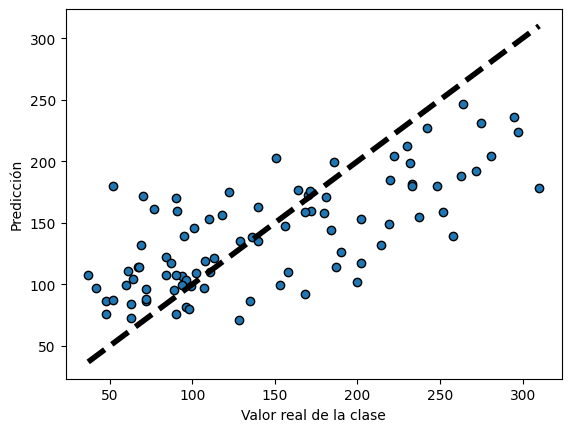

In [14]:
grafica_real_vs_pred(y_test, y_pred, metricas, model) # mostrar el valor real respecto la predicción

In [16]:
r2 = r2_score(y_test, y_pred)
print("Test results (r2)", r2)

Test results (r2) 0.4937125101265256
